# 14 - New Primitives for Euclidean Geometry

This notebook is a standalone, executable replacement for Chapter 14 of *Geometric Algebra for Computer Science*. The source span was verified before writing: printed pages 397-436 correspond to PDF pages 424-463 in this copy of the book. The page just before that span is still Chapter 13, and the page just after it starts Chapter 15.

The chapter is about a change in what counts as a primitive. In the homogeneous model a line, plane, or point feels natural, while a circle or sphere is usually something assembled from equations. In the conformal model, spheres, circles, point pairs, and tangents become blade-like objects that can be constructed, transformed, intersected, and probed with the same algebraic grammar used for flats. This notebook keeps the full algebraic story in view, but it uses small numerical helpers so the ideas can be inspected without depending on a full multivector package.

The emphasis is practical. Every major claim below is paired with a plot or a numerical check: direct rounds from points, dual sphere probes, tangency as a limiting intersection, the representative paraboloid, power diagrams, sphere fitting, and a kinematics construction where an elbow locus is literally the intersection circle of two spheres.


## The Chapter Idea

A conformal point is not stored as only the Euclidean coordinates `x`. It is lifted to

```text
X = x + no + 0.5*|x|^2*ni
```

with a metric where `no` and `ni` are null and satisfy `no.ni = -1`. This lift makes Euclidean distance appear as an inner product:

```text
-2*(X.Y) = |x-y|^2
```

That identity is the small engine driving the chapter. If a point can probe another point by inner product, then a point can also probe a sphere, a plane, or a fitted primitive. A dual sphere centered at `c` with radius `r` is represented by

```text
S = C - 0.5*r^2*ni
```

and a point `X` lies on the sphere when `X.S = 0`. Multiplying that inner product by `-2` gives the classical power of a point:

```text
-2*(X.S) = |x-c|^2 - r^2
```

The direct version points the other way. If the data you have are points on the object, you form an oriented round from those points: two points define a point pair, three define a circle, and four noncoplanar points define a sphere. In this notebook the direct construction is recovered with Euclidean linear algebra so that the geometry is transparent. The conformal interpretation is that these point-built objects are direct rounds, while their probe-ready center-radius forms are dual rounds.


## Translation Guide

| Geometric idea | Classical view | Conformal view used here | Executable check |
|---|---|---|---|
| Point | Coordinate vector `x` | Null vector `X = x + no + 0.5*|x|^2*ni` | `X.X == 0` and distance from inner product |
| Dual sphere | Equation `|x-c|^2-r^2 = 0` | Probe vector `S = C - 0.5*r^2*ni` | `sphere_power(x, S)` is zero on the shell |
| Direct point pair | Two endpoints | Oriented 0-round through two conformal points | midpoint, half-distance, direction |
| Direct circle | Three points | Oriented 1-round through three conformal points | all three points share one center and radius |
| Direct sphere | Four points | Oriented 2-round through four conformal points | all four powers vanish against recovered dual |
| Tangent | A contact element at one point | A zero-radius round with a direction attached | limiting intersection of touching spheres |
| Representative paraboloid | Graph `z = 0.5*(x^2+y^2)` | A 2-D picture of the conformal point lift | circles appear as plane cuts |
| Power diagram | Cells by smallest power | Inner-product comparisons with dual spheres | radical axes have equal powers |
| Kinematic elbow locus | Constraints from two link lengths | Intersection circle of two spheres | both link distances are preserved |

The helper module intentionally stays modest. It is not a full geometric algebra engine. It gives just enough conformal arithmetic to make the chapter's primitive vocabulary concrete and testable.


## Notebook Route

1. Import the helper module and set up artifact paths.
2. Run small invariants for conformal points, spheres, tangents, paraboloid planes, power ties, fitting, and kinematics.
3. Build direct rounds from point data: a point pair, a circle, and a sphere.
4. Probe the same sphere in dual form and read power values as inside, on, or outside.
5. Watch two spheres pass through real intersection, tangent contact, and imaginary intersection.
6. Draw a tangent bundle sample on a sphere.
7. Use the representative paraboloid to see why circles can be plane sections.
8. Build a weighted power diagram, with ordinary Voronoi as the zero-radius special case.
9. Fit a sphere to noisy points and let a conformal SVD fit choose a plane for coplanar data.
10. Use sphere intersection as a kinematics primitive for a two-link arm.
11. Finish with artifact and invariant assertions.


In [1]:
from __future__ import annotations

from itertools import combinations
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
from IPython.display import IFrame, display

# Find the project root even if the notebook is opened from this chapter folder.
PROJECT_ROOT = Path.cwd()
for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / "utils" / "chapter14_rounds.py").exists():
        PROJECT_ROOT = candidate
        break

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils.chapter14_rounds import (
    Circle3D,
    Sphere3D,
    choose_elbow_on_circle,
    circle_from_points,
    circle_plane_on_paraboloid,
    conformal_norm2,
    conformal_point,
    distance_squared_from_inner,
    dual_sphere,
    fit_conformal_primitive,
    fit_sphere_least_squares,
    normalize_rows,
    paraboloid_grid,
    paraboloid_tangent_plane,
    point_pair_from_points,
    power_diagram_grid,
    power_values,
    radical_axis_segment,
    sample_circle,
    sample_sphere_mesh,
    sanity_checks,
    sphere_from_points,
    sphere_power,
    tangent_frame_on_sphere,
    two_link_elbow_circle,
    two_sphere_intersection,
)

np.set_printoptions(precision=4, suppress=True)

ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "chapter-14"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
artifact_paths: dict[str, str] = {}


def rel(path: Path) -> str:
    return path.resolve().relative_to(PROJECT_ROOT.resolve()).as_posix()


def save_plotly(fig: go.Figure, filename: str, *, height: int = 560) -> Path:
    path = ARTIFACT_DIR / filename
    fig.write_html(path, include_plotlyjs="cdn", full_html=True)
    artifact_paths[filename] = rel(path)
    print(f"saved {rel(path)}")
    display(IFrame(src=rel(path), width="100%", height=height))
    return path


def save_matplotlib(fig: plt.Figure, filename: str) -> Path:
    path = ARTIFACT_DIR / filename
    fig.savefig(path, dpi=170, bbox_inches="tight")
    artifact_paths[filename] = rel(path)
    print(f"saved {rel(path)}")
    return path


def curve_trace(points: np.ndarray, name: str, color: str, width: int = 5) -> go.Scatter3d:
    return go.Scatter3d(
        x=points[:, 0],
        y=points[:, 1],
        z=points[:, 2],
        mode="lines",
        name=name,
        line=dict(color=color, width=width),
    )


def point_trace(points: np.ndarray, labels: list[str], name: str, color: str) -> go.Scatter3d:
    return go.Scatter3d(
        x=points[:, 0],
        y=points[:, 1],
        z=points[:, 2],
        mode="markers+text",
        name=name,
        text=labels,
        textposition="top center",
        marker=dict(size=5, color=color),
    )


PROJECT_ROOT


WindowsPath('D:/Geometry')

## Helper Sanity Check

Before making bigger figures, run the helper module's own tiny test suite. These checks are deliberately diverse: a null point check, distance from inner product, sphere incidence, circle recovery, tangent contact, tangent-frame orthogonality, representative-paraboloid height, radical-axis equality, sphere fitting, plane detection, and inverse-kinematics link lengths.

This first cell is a smoke test for the whole notebook. If it fails, the later pictures may still render, but their interpretation would be suspect.


In [2]:
checks = sanity_checks()
checks


{'conformal_point_null_residual': 0.0,
 'distance_identity_residual': 2.220446049250313e-16,
 'sphere_incidence_max_abs_power': 1.1102230246251565e-16,
 'circle_radius_spread': 2.220446049250313e-16,
 'tangent_intersection_kind': 'tangent',
 'tangent_radius_squared': 0.0,
 'sphere_tangent_frame_dot_error': 1.1102230246251565e-16,
 'paraboloid_tangent_height_error': 0.0,
 'power_radical_axis_tie_error': 0.0,
 'sphere_fit_center_error': 4.710277376051325e-16,
 'conformal_fit_plane_kind': 'plane',
 'ik_upper_length_error': 0.0,
 'ik_lower_length_error': 0.0}

## 1. Direct Rounds From Point Data

The direct construction starts from incidence data. If the user gives two points, the primitive is not "a segment plus two endpoint records"; it is a point pair, a single oriented 0-round. Three points define a circle with a carrier plane. Four noncoplanar points define a sphere. The conformal algebra packages these as outer products of point representatives, but the geometric parameters can be recovered with ordinary linear solves.

This matters because a direct round carries more than a picture. It has orientation, a carrier, a center, a radius, and a weight. Here we focus on the parameters that can be checked numerically: every defining point lies at the recovered radius from the recovered center.


In [3]:
pair_points = np.array([[-1.95, -0.95, -0.2], [-0.75, 0.65, 0.55]])
circle_points = np.array(
    [
        [0.25, -1.15, 0.15],
        [1.75, -0.4, 0.55],
        [0.7, 0.85, -0.05],
    ]
)
sphere_points = np.array(
    [
        [-0.95, 0.55, -0.45],
        [0.95, 0.15, -0.7],
        [0.25, 1.35, 0.35],
        [-0.15, 0.45, 1.25],
    ]
)

pair = point_pair_from_points(pair_points[0], pair_points[1])
circle = circle_from_points(*circle_points)
sphere = sphere_from_points(*sphere_points)

circle_samples = sample_circle(circle, 220)
sx, sy, sz = sample_sphere_mesh(sphere, u_count=54, v_count=28)

fig = go.Figure()
fig.add_surface(
    x=sx,
    y=sy,
    z=sz,
    name="sphere through four points",
    opacity=0.22,
    colorscale=[[0, "#8ecae6"], [1, "#219ebc"]],
    showscale=False,
)
fig.add_trace(curve_trace(circle_samples, "circle through three points", "#2a9d8f", 7))
fig.add_trace(
    curve_trace(np.vstack([pair.point_a, pair.point_b]), "direct point pair", "#e76f51", 8)
)
fig.add_trace(point_trace(pair_points, ["p", "q"], "point-pair endpoints", "#d1495b"))
fig.add_trace(point_trace(circle_points, ["a", "b", "c"], "circle points", "#15616d"))
fig.add_trace(point_trace(sphere_points, ["s1", "s2", "s3", "s4"], "sphere points", "#023047"))
fig.add_trace(point_trace(np.array([pair.center, circle.center, sphere.center]), ["pair center", "circle center", "sphere center"], "centers", "#111111"))

fig.update_layout(
    title="Direct rounds recovered from their spanning points",
    scene=dict(aspectmode="data", xaxis_title="x", yaxis_title="y", zaxis_title="z"),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0),
    margin=dict(l=0, r=0, b=0, t=72),
)
direct_rounds_path = save_plotly(fig, "direct-rounds.html")

round_summary = {
    "point_pair_center": pair.center.tolist(),
    "point_pair_radius": pair.radius,
    "circle_center": circle.center.tolist(),
    "circle_radius": circle.radius,
    "sphere_center": sphere.center.tolist(),
    "sphere_radius": sphere.radius,
}
round_summary


saved artifacts/chapter-14/direct-rounds.html


{'point_pair_center': [-1.35, -0.14999999999999997, 0.17500000000000002],
 'point_pair_radius': 1.0680004681646913,
 'circle_center': [0.7642872536372406,
  -0.20379777025881607,
  0.16291861809562827],
 'circle_radius': 1.0770129662703343,
 'sphere_center': [0.055679862306368254,
  0.19447791164658645,
  0.09700229489386118],
 'sphere_radius': 1.198749119446967}

The plot shows the same grammar at three dimensions of roundness. A point pair is a sphere on a line: its carrier is one-dimensional, and the "shell" has two points. A circle is a sphere on a plane: its carrier is two-dimensional, and the shell is one-dimensional. A sphere in 3-D is the full carrier case: a two-dimensional shell in a three-dimensional carrier.

The conformal lesson is not that circles and spheres have become mysterious. It is the opposite: once embedded, they can be moved and intersected by the same mechanisms that already handle lines and planes. The next cell switches from direct construction to a dual probe.


In [4]:
S = dual_sphere(sphere.center, sphere.radius)
probe_points = np.array(
    [
        sphere_points[0],
        sphere.center,
        sphere.center + np.array([sphere.radius, 0.0, 0.0]),
        sphere.center + np.array([1.35 * sphere.radius, 0.0, 0.0]),
    ]
)
probe_names = ["defining point", "center", "axis shell point", "outside point"]

probe_rows = []
for name, point in zip(probe_names, probe_points):
    power = sphere_power(point, S)
    if abs(power) < 1e-8:
        region = "on"
    elif power < 0:
        region = "inside"
    else:
        region = "outside"
    probe_rows.append({"name": name, "point": point.round(4).tolist(), "power": float(power), "region": region})

max_defining_power = max(abs(sphere_power(point, S)) for point in sphere_points)
distance_identity = distance_squared_from_inner(sphere_points[0], sphere_points[1]) - float(
    np.dot(sphere_points[0] - sphere_points[1], sphere_points[0] - sphere_points[1])
)
assert max_defining_power < 1e-8
assert abs(distance_identity) < 1e-10
probe_rows


[{'name': 'defining point',
  'point': [-0.95, 0.55, -0.45],
  'power': 2.220446049250313e-16,
  'region': 'on'},
 {'name': 'center',
  'point': [0.0557, 0.1945, 0.097],
  'power': -1.436999451374879,
  'region': 'inside'},
 {'name': 'axis shell point',
  'point': [1.2544, 0.1945, 0.097],
  'power': -0.0,
  'region': 'on'},
 {'name': 'outside point',
  'point': [1.674, 0.1945, 0.097],
  'power': 1.1819320487558382,
  'region': 'outside'}]

## 2. Tangents as Limiting Intersections

Tangents enter naturally when an intersection round loses radius. Put two equal spheres at centers separated by distance `2`. If the common radius is greater than `1`, the spheres meet in a real circle. If the radius is exactly `1`, the intersection circle has radius zero: one contact point plus a tangent direction. If the radius is less than `1`, the same algebraic formula produces a negative squared radius, which is best treated as an imaginary circle rather than as a broken case.

This is one of the pleasant habits of the conformal model. A tangent is not a special exception bolted onto the intersection code. It is the zero-size member of the round family.


saved artifacts/chapter-14/tangent-transition.png


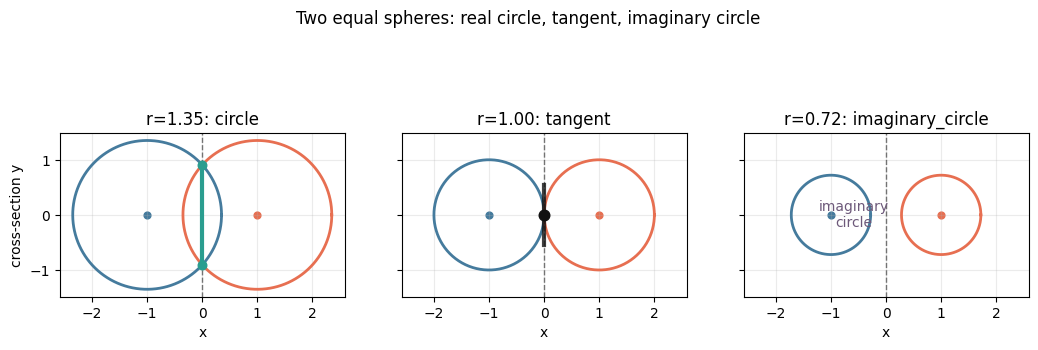

[('circle', 0.8225000000000002),
 ('tangent', 0.0),
 ('imaginary_circle', -0.48160000000000003)]

In [5]:
left = np.array([-1.0, 0.0, 0.0])
right = np.array([1.0, 0.0, 0.0])
radii = [1.35, 1.0, 0.72]

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.7), sharex=True, sharey=True)
theta = np.linspace(0.0, 2.0 * np.pi, 360)

tangent_results = []
for ax, radius in zip(axes, radii):
    intersection = two_sphere_intersection(left, radius, right, radius)
    tangent_results.append(intersection)
    for center, color in [(left, "#457b9d"), (right, "#e76f51")]:
        ax.plot(center[0] + radius * np.cos(theta), radius * np.sin(theta), color=color, lw=2)
        ax.scatter([center[0]], [0.0], color=color, s=24)
    ax.axvline(intersection.center[0], color="#333333", lw=1, ls="--", alpha=0.65)
    if intersection.kind == "circle":
        h = intersection.radius
        ax.scatter([intersection.center[0], intersection.center[0]], [h, -h], color="#2a9d8f", s=38, zorder=5)
        ax.plot([intersection.center[0], intersection.center[0]], [-h, h], color="#2a9d8f", lw=3)
    elif intersection.kind == "tangent":
        ax.scatter([intersection.center[0]], [0.0], color="#111111", s=58, zorder=5)
        ax.plot([intersection.center[0], intersection.center[0]], [-0.55, 0.55], color="#111111", lw=3, alpha=0.8)
    else:
        ax.text(-0.58, 0.0, "imaginary\ncircle", ha="center", va="center", color="#6d597a")
    ax.set_title(f"r={radius:.2f}: {intersection.kind}")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.25)
    ax.set_xlabel("x")

axes[0].set_ylabel("cross-section y")
fig.suptitle("Two equal spheres: real circle, tangent, imaginary circle", y=1.05)
tangent_transition_path = save_matplotlib(fig, "tangent-transition.png")
plt.show()

assert tangent_results[1].kind == "tangent"
assert abs(tangent_results[1].signed_radius_squared) < 1e-12
[(item.kind, item.signed_radius_squared) for item in tangent_results]


A tangent also carries direction. At a point on a sphere, the radial direction is normal and every vector perpendicular to it is tangent. A conformal tangent element packages the contact point with such a local direction or local area. The next figure draws a single tangent patch on a sphere. It is not meant as a tiny physical square glued to the surface. It is a local linear element with an independently meaningful weight.


In [6]:
tangent_sphere = Sphere3D(center=np.array([0.0, 0.0, 0.0]), radius=1.45, orientation=1.0)
contact, tu, tv = tangent_frame_on_sphere(tangent_sphere.center, tangent_sphere.radius, theta=0.8, phi=0.92)
patch_scale = 0.56
patch_corners = np.array(
    [
        contact - patch_scale * tu - patch_scale * tv,
        contact + patch_scale * tu - patch_scale * tv,
        contact + patch_scale * tu + patch_scale * tv,
        contact - patch_scale * tu + patch_scale * tv,
    ]
)
sx, sy, sz = sample_sphere_mesh(tangent_sphere, u_count=52, v_count=26)

fig = go.Figure()
fig.add_surface(x=sx, y=sy, z=sz, opacity=0.25, colorscale=[[0, "#bde0fe"], [1, "#48cae4"]], showscale=False, name="sphere")
fig.add_trace(
    go.Mesh3d(
        x=patch_corners[:, 0],
        y=patch_corners[:, 1],
        z=patch_corners[:, 2],
        i=[0, 0],
        j=[1, 2],
        k=[2, 3],
        name="tangent patch",
        color="#f4a261",
        opacity=0.72,
    )
)
fig.add_trace(point_trace(np.array([contact]), ["contact"], "contact point", "#111111"))
for direction, name, color in [(tu, "tangent u", "#2a9d8f"), (tv, "tangent v", "#e76f51")]:
    segment = np.vstack([contact, contact + 0.82 * direction])
    fig.add_trace(curve_trace(segment, name, color, 7))
radial = np.vstack([np.zeros(3), contact])
fig.add_trace(curve_trace(radial, "radial normal", "#264653", 5))
fig.update_layout(
    title="A tangent element as contact point plus local direction data",
    scene=dict(aspectmode="data", xaxis_title="x", yaxis_title="y", zaxis_title="z"),
    margin=dict(l=0, r=0, b=0, t=60),
)
tangent_bundle_path = save_plotly(fig, "tangent-bundle.html")

assert abs(float(np.dot(contact - tangent_sphere.center, tu))) < 1e-12
assert abs(float(np.dot(contact - tangent_sphere.center, tv))) < 1e-12


saved artifacts/chapter-14/tangent-bundle.html


## 3. The Representative Paraboloid

For 2-D Euclidean geometry, the conformal point lift can be pictured by drawing the coefficient of `ni` as a vertical coordinate:

```text
(x, y) -> (x, y, 0.5*(x^2+y^2))
```

The lifted points sit on a paraboloid. This is not the whole conformal model, because the metric information is not captured by ordinary 3-D dot products in the drawing. Still, it gives a valuable intuition: a point's own dual representation is the tangent plane to the paraboloid at that point, and a Euclidean circle is the intersection of the paraboloid with an affine plane.

That last statement is the bridge to power diagrams. A sphere or circle power function is a vertical difference between a paraboloid and a plane.


In [7]:
xx, yy, zz = paraboloid_grid((-2.4, 2.4), (-2.1, 2.1), 80)
point2 = np.array([0.95, -0.65])
circle_center2 = np.array([-0.35, 0.45])
circle_radius2 = 1.15
tx, ty, tz = paraboloid_tangent_plane(point2, (-2.4, 2.4), (-2.1, 2.1), 12)
cx, cy, cz = circle_plane_on_paraboloid(circle_center2, circle_radius2, (-2.4, 2.4), (-2.1, 2.1), 12)

angle = np.linspace(0.0, 2.0 * np.pi, 220)
circle_xy = circle_center2 + circle_radius2 * np.column_stack([np.cos(angle), np.sin(angle)])
circle_z = 0.5 * np.sum(circle_xy * circle_xy, axis=1)
tangent_height = 0.5 * float(np.dot(point2, point2))

fig = go.Figure()
fig.add_surface(x=xx, y=yy, z=zz, colorscale=[[0, "#f1faee"], [1, "#a8dadc"]], opacity=0.78, showscale=False, name="representative paraboloid")
fig.add_surface(x=tx, y=ty, z=tz, colorscale=[[0, "#ffd166"], [1, "#f4a261"]], opacity=0.48, showscale=False, name="point tangent plane")
fig.add_surface(x=cx, y=cy, z=cz, colorscale=[[0, "#cdb4db"], [1, "#6d597a"]], opacity=0.42, showscale=False, name="circle plane")
fig.add_trace(go.Scatter3d(x=circle_xy[:, 0], y=circle_xy[:, 1], z=circle_z, mode="lines", name="circle as plane cut", line=dict(color="#7b2cbf", width=7)))
fig.add_trace(go.Scatter3d(x=[point2[0]], y=[point2[1]], z=[tangent_height], mode="markers+text", text=["point X"], textposition="top center", marker=dict(size=5, color="#111111"), name="lifted point"))
fig.update_layout(
    title="Representative paraboloid: points, tangent plane, and a circle plane",
    scene=dict(aspectmode="data", xaxis_title="x", yaxis_title="y", zaxis_title="0.5|x|^2"),
    margin=dict(l=0, r=0, b=0, t=62),
)
paraboloid_path = save_plotly(fig, "representative-paraboloid.html")

plane_heights = circle_center2[0] * circle_xy[:, 0] + circle_center2[1] * circle_xy[:, 1] + 0.5 * (
    circle_radius2**2 - float(np.dot(circle_center2, circle_center2))
)
assert np.max(np.abs(plane_heights - circle_z)) < 1e-10


saved artifacts/chapter-14/representative-paraboloid.html


## 4. Voronoi and Power Diagrams

The dual-sphere probe computes a power value. For an ordinary Voronoi diagram, all radii are zero and the winning site is the one with smallest squared distance. For a power diagram, each site can carry a radius and the winning value becomes

```text
power_i(x) = |x-c_i|^2 - r_i^2
```

The cell boundary between two sites is a radical axis, where the two powers are equal. Algebraically this boundary is linear because the `|x|^2` terms cancel. In conformal terms, the equality is an equality of inner-product probes against two dual circles or spheres.

The weighted diagram below is intentionally not symmetric. Larger radii expand a site's cell because they subtract more from the squared distance. If all radii are set to zero, the same helper becomes the ordinary Voronoi diagram.


In [8]:
centers2 = np.array([[-1.75, -0.65], [-0.25, 0.95], [1.25, -0.25], [0.95, 1.25]])
radii2 = np.array([0.55, 0.95, 0.35, 0.75])
xlim = (-2.7, 2.45)
ylim = (-1.8, 2.05)
gx, gy, labels, powers = power_diagram_grid(centers2, radii2, xlim, ylim, 220)
_, _, voronoi_labels, _ = power_diagram_grid(centers2, np.zeros_like(radii2), xlim, ylim, 220)
changed_fraction = float(np.mean(labels != voronoi_labels))

fig = go.Figure()
fig.add_trace(
    go.Heatmap(
        x=gx[0],
        y=gy[:, 0],
        z=labels,
        colorscale=[[0, "#edf6f9"], [0.33, "#ffddd2"], [0.66, "#cdeac0"], [1, "#d7e3fc"]],
        opacity=0.72,
        showscale=False,
        name="winning power cell",
    )
)
for i, (center, radius) in enumerate(zip(centers2, radii2)):
    t = np.linspace(0.0, 2.0 * np.pi, 160)
    ring = center + radius * np.column_stack([np.cos(t), np.sin(t)])
    fig.add_trace(go.Scatter(x=ring[:, 0], y=ring[:, 1], mode="lines", name=f"site {i} radius", line=dict(width=3)))
    fig.add_trace(go.Scatter(x=[center[0]], y=[center[1]], mode="markers+text", text=[f"c{i}"], textposition="top center", marker=dict(size=10, color="#111111"), name=f"site {i}"))

axis_errors = []
for i, j in combinations(range(len(centers2)), 2):
    segment = radical_axis_segment(centers2[i], radii2[i], centers2[j], radii2[j], xlim, ylim)
    if len(segment) == 2:
        fig.add_trace(go.Scatter(x=segment[:, 0], y=segment[:, 1], mode="lines", name=f"axis {i}-{j}", line=dict(color="#333333", width=1, dash="dash"), opacity=0.58))
        p = power_values(segment[0], centers2, radii2)
        axis_errors.append(abs(float(p[i] - p[j])))

fig.update_layout(
    title=f"Weighted power diagram; {changed_fraction:.1%} of grid cells differ from ordinary Voronoi",
    xaxis=dict(scaleanchor="y", title="x"),
    yaxis=dict(title="y"),
    margin=dict(l=0, r=0, b=0, t=58),
    legend=dict(orientation="h", yanchor="bottom", y=1.03, xanchor="left", x=0),
)
power_diagram_path = save_plotly(fig, "power-diagram.html", height=620)

assert max(axis_errors) < 1e-8
{"changed_fraction_from_voronoi": changed_fraction, "max_radical_axis_power_error": max(axis_errors)}


saved artifacts/chapter-14/power-diagram.html


{'changed_fraction_from_voronoi': 0.06367768595041322,
 'max_radical_axis_power_error': 3.552713678800501e-15}

## 5. Fitting a Sphere

The same primitive vocabulary is useful when data are noisy. A sphere can be fitted by writing its classical equation as a linear least-squares problem:

```text
x^2 + y^2 + z^2 + a*x + b*y + c*z + d = 0
```

After solving for `a, b, c, d`, the center is `(-a/2, -b/2, -c/2)`. This is not a perfect statistical estimator for every measurement model, but it is a clean executable way to recover the primitive and to check the conformal incidence equation.

The conformal version below also fits a dual primitive by SVD. It can return a sphere when the data support a sphere, or a plane when the best zero set has no finite radius. That behavior is important: a plane is not an error state in conformal geometry. It is a sphere through infinity.


In [9]:
rng = np.random.default_rng(140)
true_center = np.array([0.65, -0.35, 0.8])
true_radius = 1.25
directions = normalize_rows(rng.normal(size=(90, 3)))
noise = 0.035 * rng.normal(size=(90, 1))
cloud = true_center + (true_radius + noise) * directions

fit_sphere = fit_sphere_least_squares(cloud)
fit_dual = fit_conformal_primitive(cloud)
fit_surface = Sphere3D(fit_sphere.center, fit_sphere.radius, 1.0)
sx, sy, sz = sample_sphere_mesh(fit_surface, u_count=52, v_count=26)

fig = go.Figure()
fig.add_trace(go.Scatter3d(x=cloud[:, 0], y=cloud[:, 1], z=cloud[:, 2], mode="markers", marker=dict(size=3, color="#264653", opacity=0.72), name="noisy samples"))
fig.add_surface(x=sx, y=sy, z=sz, colorscale=[[0, "#ffd6a5"], [1, "#fb8500"]], opacity=0.28, showscale=False, name="fitted sphere")
fig.add_trace(point_trace(np.array([true_center, fit_sphere.center]), ["true center", "fit center"], "centers", "#111111"))
fig.update_layout(
    title="Least-squares sphere fit from noisy shell samples",
    scene=dict(aspectmode="data", xaxis_title="x", yaxis_title="y", zaxis_title="z"),
    margin=dict(l=0, r=0, b=0, t=58),
)
sphere_fit_path = save_plotly(fig, "sphere-fit.html")

fit_report = {
    "true_center": true_center.tolist(),
    "fit_center": fit_sphere.center.tolist(),
    "center_error": float(np.linalg.norm(fit_sphere.center - true_center)),
    "true_radius": true_radius,
    "fit_radius": fit_sphere.radius,
    "radius_error": abs(float(fit_sphere.radius - true_radius)),
    "conformal_fit_kind": fit_dual.kind,
    "conformal_fit_residual_rms": fit_dual.residual_rms,
}
assert fit_report["center_error"] < 0.04
assert fit_report["radius_error"] < 0.04
fit_report


saved artifacts/chapter-14/sphere-fit.html


{'true_center': [0.65, -0.35, 0.8],
 'fit_center': [0.6530544910960241, -0.3591579664099964, 0.7845854950728178],
 'center_error': 0.018188051758570467,
 'true_radius': 1.25,
 'fit_radius': 1.255870063967451,
 'radius_error': 0.005870063967450934,
 'conformal_fit_kind': 'sphere',
 'conformal_fit_residual_rms': 0.04372914051058402}

In [10]:
px, py = np.meshgrid(np.linspace(-1.4, 1.4, 5), np.linspace(-1.1, 1.1, 5))
plane_cloud = np.column_stack(
    [
        px.ravel(),
        py.ravel(),
        0.45 + 0.18 * px.ravel() - 0.12 * py.ravel(),
    ]
)
plane_fit = fit_conformal_primitive(plane_cloud)
assert plane_fit.kind == "plane"

plane_x, plane_y = np.meshgrid(np.linspace(-1.55, 1.55, 4), np.linspace(-1.25, 1.25, 4))
normal = plane_fit.normal
offset = plane_fit.offset
plane_z = (offset - normal[0] * plane_x - normal[1] * plane_y) / normal[2]

fig = go.Figure()
fig.add_trace(go.Scatter3d(x=plane_cloud[:, 0], y=plane_cloud[:, 1], z=plane_cloud[:, 2], mode="markers", marker=dict(size=4, color="#1d3557"), name="coplanar samples"))
fig.add_surface(x=plane_x, y=plane_y, z=plane_z, colorscale=[[0, "#caffbf"], [1, "#52b788"]], opacity=0.45, showscale=False, name="conformal plane fit")
fig.update_layout(
    title="Conformal primitive fit chooses a plane for coplanar data",
    scene=dict(aspectmode="data", xaxis_title="x", yaxis_title="y", zaxis_title="z"),
    margin=dict(l=0, r=0, b=0, t=58),
)
plane_fit_path = save_plotly(fig, "primitive-plane-fit.html")

plane_report = {
    "kind": plane_fit.kind,
    "normal": plane_fit.normal.round(5).tolist(),
    "offset": float(plane_fit.offset),
    "residual_rms": plane_fit.residual_rms,
}
assert plane_fit.residual_rms < 1e-12
plane_report


saved artifacts/chapter-14/primitive-plane-fit.html


{'kind': 'plane',
 'normal': [-0.17593, 0.11729, 0.97739],
 'offset': 0.439825754917302,
 'residual_rms': 3.5002851218456244e-16}

## 6. Kinematics Application

A two-link arm offers a compact application. The shoulder is fixed. The hand target is fixed. The elbow must be at distance `L1` from the shoulder and at distance `L2` from the target. That makes the elbow locus the intersection of two spheres.

If the spheres meet in a circle, there is a continuous family of elbow poses. If they touch, the arm is fully extended or fully folded in one limiting pose. If the intersection is imaginary, the target is unreachable. This is exactly the real, tangent, imaginary classification from the tangent section, now used as a robotics calculation rather than as a pure geometric example.


In [11]:
shoulder = np.array([0.0, 0.0, 0.0])
target = np.array([1.15, 0.85, 0.58])
upper = 1.25
lower = 0.95
elbow_circle = two_link_elbow_circle(shoulder, target, upper, lower)
elbow = choose_elbow_on_circle(elbow_circle, preferred_up=(0.0, 0.0, 1.0))
circle_samples = sample_circle(elbow_circle, 240)

upper_sphere = Sphere3D(shoulder, upper, 1.0)
lower_sphere = Sphere3D(target, lower, 1.0)
ux, uy, uz = sample_sphere_mesh(upper_sphere, u_count=42, v_count=20)
lx, ly, lz = sample_sphere_mesh(lower_sphere, u_count=42, v_count=20)

fig = go.Figure()
fig.add_surface(x=ux, y=uy, z=uz, opacity=0.16, colorscale=[[0, "#90e0ef"], [1, "#0077b6"]], showscale=False, name="upper link sphere")
fig.add_surface(x=lx, y=ly, z=lz, opacity=0.16, colorscale=[[0, "#ffccd5"], [1, "#c9184a"]], showscale=False, name="lower link sphere")
fig.add_trace(curve_trace(circle_samples, "elbow locus", "#2a9d8f", 8))
fig.add_trace(curve_trace(np.vstack([shoulder, elbow, target]), "chosen arm pose", "#111111", 8))
fig.add_trace(point_trace(np.array([shoulder, elbow, target]), ["shoulder", "elbow", "target"], "joints", "#111111"))
fig.update_layout(
    title=f"Two-link kinematics as sphere intersection: {elbow_circle.kind}",
    scene=dict(aspectmode="data", xaxis_title="x", yaxis_title="y", zaxis_title="z"),
    margin=dict(l=0, r=0, b=0, t=58),
)
kinematics_path = save_plotly(fig, "kinematics-elbow-circle.html")

ik_report = {
    "intersection_kind": elbow_circle.kind,
    "elbow_circle_center": elbow_circle.center.tolist(),
    "elbow_circle_radius": elbow_circle.radius,
    "chosen_elbow": elbow.tolist(),
    "upper_error": abs(float(np.linalg.norm(elbow - shoulder)) - upper),
    "lower_error": abs(float(np.linalg.norm(target - elbow)) - lower),
}
assert ik_report["upper_error"] < 1e-10
assert ik_report["lower_error"] < 1e-10
ik_report


saved artifacts/chapter-14/kinematics-elbow-circle.html


{'intersection_kind': 'circle',
 'elbow_circle_center': [0.7343600403124213,
  0.542787855883094,
  0.3703728898966995],
 'elbow_circle_radius': 0.7690387487817111,
 'chosen_elbow': [0.5019198481470581, 0.37098423558695603, 1.083026852382708],
 'upper_error': 0.0,
 'lower_error': 1.1102230246251565e-16}

## Applied Lab: Reachability Sweep

The following small sweep changes only the target position. The helper does not need a separate "robotics mode"; it simply classifies the same two-sphere intersection as real, tangent, or imaginary. This is the chapter's main engineering pattern: once a primitive has the right representation, separate applications become smaller because they reuse the same geometric operations.

There is another reason this example belongs in a chapter about new primitives. Many coordinate treatments of inverse kinematics begin by choosing an angle convention, deriving trigonometric equations, and then adding case logic for reachability. The round-based treatment starts from constraints instead. The upper link says that the elbow is on a sphere around the shoulder. The lower link says that the elbow is on a sphere around the target. The meet of those constraints is the answer space. Only after that answer space is known do we choose a particular elbow, for example the one most aligned with a preferred up direction. This order keeps modeling and choice separate: the circle is the geometric fact, while the selected point is a control decision.

The same separation is useful outside robotics. A camera calibration routine may fit spheres or planes before deciding which measurements to keep. A collision query may compute a tangent contact before choosing a response impulse. A mesh algorithm may compare powers before deciding which vertex owns a sample. In each case, the conformal primitive carries the metric information first, and the application policy comes later.

That is also why the final sanity cell checks artifacts and invariants rather than only checking that plots were produced. The chapter replacement should behave like a small lab: change the numbers, rerun the cells, and expect the geometric relationships to keep answering back in measurable form.


In [12]:
sweep_targets = np.array(
    [
        [0.85, 0.15, 0.25],
        [1.55, 0.15, 0.25],
        [2.20, 0.15, 0.25],
        [0.35, 0.05, 0.05],
        [0.05, 0.0, 0.0],
    ]
)
sweep_rows = []
for item in sweep_targets:
    try:
        locus = two_link_elbow_circle(shoulder, item, upper, lower)
        sweep_rows.append(
            {
                "target": item.round(3).tolist(),
                "kind": locus.kind,
                "signed_radius_squared": locus.signed_radius_squared,
            }
        )
    except ValueError as exc:
        sweep_rows.append({"target": item.round(3).tolist(), "kind": "degenerate", "note": str(exc)})

sweep_path = ARTIFACT_DIR / "kinematics-reachability-sweep.json"
sweep_path.write_text(json.dumps(sweep_rows, indent=2), encoding="utf-8")
artifact_paths[sweep_path.name] = rel(sweep_path)
print(f"saved {rel(sweep_path)}")
sweep_rows


saved artifacts/chapter-14/kinematics-reachability-sweep.json


[{'target': [0.85, 0.15, 0.25],
  'kind': 'circle',
  'signed_radius_squared': 0.895764318885449},
 {'target': [1.55, 0.15, 0.25],
  'kind': 'circle',
  'signed_radius_squared': 0.5668461055276379},
 {'target': [2.2, 0.15, 0.25],
  'kind': 'imaginary_circle',
  'signed_radius_squared': -0.02086167512690351},
 {'target': [0.35, 0.05, 0.05],
  'kind': 'circle',
  'signed_radius_squared': 0.3465073529411762},
 {'target': [0.05, 0.0, 0.0],
  'kind': 'imaginary_circle',
  'signed_radius_squared': -42.328124999999986}]

## Final Sanity Checks

The notebook has made a lot of visual claims, so it ends by checking the computational claims in one place. The checks below assert that:

- conformal point representatives are null;
- point-point distance is recovered from the conformal inner product;
- defining points lie on the recovered sphere;
- the tangent example has zero squared intersection radius;
- tangent directions are perpendicular to the sphere radius;
- the representative-paraboloid circle really lies in its plane;
- radical-axis points have equal power;
- sphere fitting recovers the intended noisy sphere within a small tolerance;
- conformal primitive fitting detects a plane for coplanar data;
- the kinematic elbow satisfies both link-length constraints;
- every declared artifact exists on disk.


In [13]:
final_checks = sanity_checks()
numeric_thresholds = {
    "conformal_point_null_residual": 1e-10,
    "distance_identity_residual": 1e-10,
    "sphere_incidence_max_abs_power": 1e-8,
    "circle_radius_spread": 1e-10,
    "tangent_radius_squared": 1e-12,
    "sphere_tangent_frame_dot_error": 1e-10,
    "paraboloid_tangent_height_error": 1e-10,
    "power_radical_axis_tie_error": 1e-8,
    "sphere_fit_center_error": 1e-10,
    "ik_upper_length_error": 1e-10,
    "ik_lower_length_error": 1e-10,
}
for key, threshold in numeric_thresholds.items():
    assert float(final_checks[key]) < threshold, (key, final_checks[key], threshold)
assert final_checks["tangent_intersection_kind"] == "tangent"
assert final_checks["conformal_fit_plane_kind"] == "plane"

required_artifacts = [
    direct_rounds_path,
    tangent_transition_path,
    tangent_bundle_path,
    paraboloid_path,
    power_diagram_path,
    sphere_fit_path,
    plane_fit_path,
    kinematics_path,
    sweep_path,
]
for path in required_artifacts:
    assert Path(path).exists(), path

summary = {
    "verified_source_span": {
        "printed_pages": "397-436",
        "pdf_pages": "424-463",
        "previous_pdf_page": "423 ends Chapter 13",
        "next_pdf_page": "464 starts Chapter 15",
    },
    "artifacts": [rel(Path(path)) for path in required_artifacts],
    "final_checks": final_checks,
}
summary_path = ARTIFACT_DIR / "chapter14-validation-summary.json"
summary_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")
artifact_paths[summary_path.name] = rel(summary_path)
print(f"saved {rel(summary_path)}")
summary


saved artifacts/chapter-14/chapter14-validation-summary.json


{'verified_source_span': {'printed_pages': '397-436',
  'pdf_pages': '424-463',
  'previous_pdf_page': '423 ends Chapter 13',
  'next_pdf_page': '464 starts Chapter 15'},
 'artifacts': ['artifacts/chapter-14/direct-rounds.html',
  'artifacts/chapter-14/tangent-transition.png',
  'artifacts/chapter-14/tangent-bundle.html',
  'artifacts/chapter-14/representative-paraboloid.html',
  'artifacts/chapter-14/power-diagram.html',
  'artifacts/chapter-14/sphere-fit.html',
  'artifacts/chapter-14/primitive-plane-fit.html',
  'artifacts/chapter-14/kinematics-elbow-circle.html',
  'artifacts/chapter-14/kinematics-reachability-sweep.json'],
 'final_checks': {'conformal_point_null_residual': 0.0,
  'distance_identity_residual': 2.220446049250313e-16,
  'sphere_incidence_max_abs_power': 1.1102230246251565e-16,
  'circle_radius_spread': 2.220446049250313e-16,
  'tangent_intersection_kind': 'tangent',
  'tangent_radius_squared': 0.0,
  'sphere_tangent_frame_dot_error': 1.1102230246251565e-16,
  'parabo

## Chapter Takeaways

The conformal model enlarges the primitive vocabulary of Euclidean geometry. Spheres, circles, point pairs, and tangents no longer have to be treated as second-class objects assembled from coordinate equations. They can be built from points, probed by inner products, intersected, transformed, and fitted.

Direct and dual representations answer different questions. Direct rounds are natural when incidence data define the object: two points for a point pair, three for a circle, four for a sphere. Dual rounds are natural when the object is used as a test: a point probes a dual sphere and receives a power value. The notebook's sphere examples use both views and verify that they agree.

Tangents are limiting rounds, not exceptions. The same two-sphere intersection formula moves from a real circle to a zero-radius tangent and then to an imaginary circle. That continuity is why the kinematics example can classify reachable, limiting, and unreachable targets with the same primitive.

The representative paraboloid turns the conformal lift into a picture. It shows why point representatives are null, why a point has a tangent plane, and why circles appear as plane cuts. Power diagrams reuse the same idea: compare vertical gaps, or equivalently compare inner-product probes against dual circles.

Finally, fitting reveals the practical value of this vocabulary. A noisy shell can be summarized as a sphere. A coplanar cloud can be summarized as a plane, which the conformal model treats as a sphere through infinity. The payoff is a geometry toolkit where the right primitive often makes the algorithm shorter than the coordinate derivation that motivated it.
